# GM Counting Experiment

## Block 1 — Loading and Inspecting the Data

The data are obtained from a GM counting experiment in Phyiscs Lab V. Two types of measurements are available:

- Background measurements
- Measurements with a Tl-204 $\beta$ source

The number of counts recorded in a fixed counting time is a discrete random variable. Therefore, for the counting experiment, the natural statistical model is the **Poisson distribution**.

Before performing parameter estimation or hypothesis testing, we first load the individual measurements and inspect the observed count distributions.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the data
file_path = "background_Tl204_observations(1)(1).xlsx"

observations = pd.read_excel(
    file_path,
    sheet_name="Observations"
)

summary = pd.read_excel(
    file_path,
    sheet_name="Summary"
)

# Display the first few observations
display(observations.head())

# Display summary information
display(summary)

,Source,Measurement No.,Counting Time (s),Counts
0,Background,1,10,5
1,Background,2,10,6
2,Background,3,10,3
3,Background,4,10,4
4,Background,5,10,1


,Source,No. of Measurements,Counting Time (s),Mean Counts,Mean Rate (counts/s)
0,Background,51,10,3.862745,0.386275
1,Tl-204 (β source),33,20,11.151515,0.557576


## Dataset

The dataset consists of two sets of measurements from the GM counting experiment:

- **Background-only measurements:** 51 independent measurements, each performed for a fixed counting time of 10 s.
- **Tl-204 + background measurements:** 30 independent measurements, each performed for a fixed counting time of 20 s.

The background-only measurements are used to estimate the background counting rate,

$$
r_b,
$$

while the measurements taken with the Tl-204 source contain contributions from both the background and the radioactive source:

$$
r_{\rm total}=r_b+r_s,
$$

where $r_s$ is the signal counting rate from the Tl-204 source.

Since the number of counts recorded in a fixed time interval is a discrete quantity, the measurements are modeled using Poisson statistics:

$$
N\sim\operatorname{Poisson}(\lambda),
$$

with

$$
\lambda=rt.
$$

The 51 background measurements therefore constrain the background rate, while the 33 source-plus-background measurements are used to estimate the total rate and, together with the background data, determine the signal rate.



## Separating Background and Source Measurements

We separate the measurements into two datasets:

$$
N_{\rm bkg} = \text{background counts}
$$

and

$$
N_{\rm source} = \text{counts measured with the Tl-204 source}.
$$

The counting times are different for the two datasets, so when comparing rates we must take the measurement time into account:

$$
R = \frac{N}{t},
$$

where $N$ is the number of observed counts and $t$ is the counting time.

In [ ]:
# Separate background and Tl-204 measurements
background = observations[
    observations["Source"] == "Background"
].copy()

source = observations[
    observations["Source"] == "Tl-204 (β source)"
].copy()

# Extract counts and counting times
bkg_counts = background["Counts"].to_numpy()
source_counts = source["Counts"].to_numpy()

bkg_time = background["Counting Time (s)"].to_numpy()
source_time = source["Counting Time (s)"].to_numpy()

print("Background measurements:", len(bkg_counts))
print("Tl-204 measurements:", len(source_counts))

print()
print("Background counting time:", np.unique(bkg_time), "s")
print("Tl-204 counting time:", np.unique(source_time), "s")

Background measurements: 51
Tl-204 measurements: 33

Background counting time: [10] s
Tl-204 counting time: [20] s


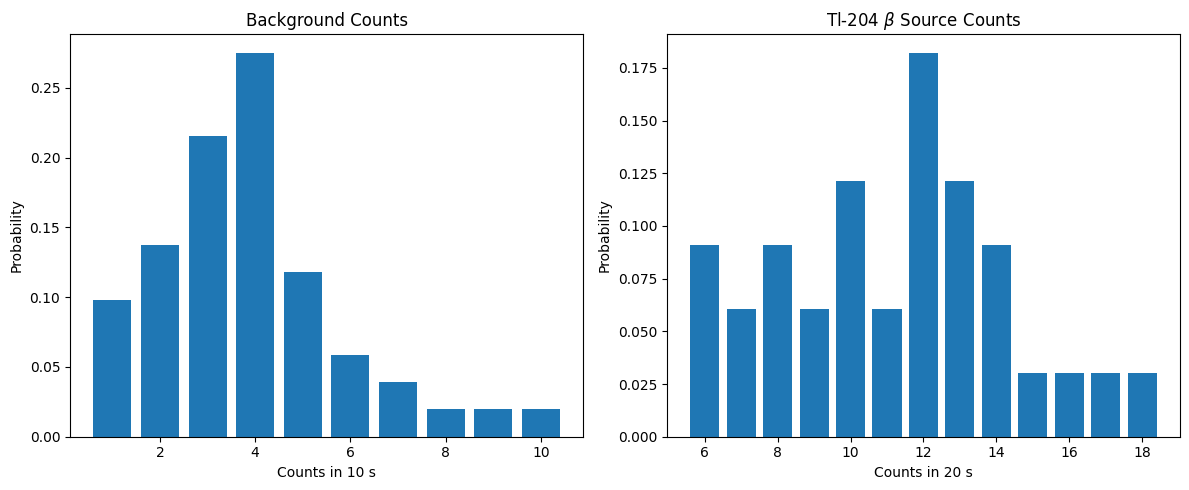

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Background
axes[0].hist(
    bkg_counts,
    bins=np.arange(
        bkg_counts.min() - 0.5,
        bkg_counts.max() + 1.5,
        1
    ),
    density=True,
    rwidth=0.8
)

axes[0].set_xlabel("Counts in 10 s")
axes[0].set_ylabel("Probability")
axes[0].set_title("Background Counts")

# Tl-204 source
axes[1].hist(
    source_counts,
    bins=np.arange(
        source_counts.min() - 0.5,
        source_counts.max() + 1.5,
        1
    ),
    density=True,
    rwidth=0.8
)

axes[1].set_xlabel("Counts in 20 s")
axes[1].set_ylabel("Probability")
axes[1].set_title(r"Tl-204 $\beta$ Source Counts")

plt.tight_layout()
plt.show()

## Initial Observation



For a Poisson random variable,

$$
P(N|\lambda)
=
\frac{\lambda^N e^{-\lambda}}{N!},
$$

where $\lambda$ is the expected number of counts during the chosen counting interval.

For a Poisson distribution,

$$
E[N]=\lambda,
\qquad
\operatorname{Var}(N)=\lambda.
$$

Thus, the data themselves can be used to estimate the expected counting rate.


# Block 2 — Maximum Likelihood Estimation of the Background Rate

For a counting experiment, the number of counts $N$ observed in a fixed time interval $t$ is naturally described by a Poisson distribution:

$$
P(N|\lambda)
=
\frac{\lambda^N e^{-\lambda}}{N!},
$$

where $\lambda$ is the expected number of counts in that time interval.

It is often more useful to express the parameter in terms of a counting rate $r$:

$$
\lambda = rt.
$$

Therefore,

$$
P(N|r)
=
\frac{(rt)^N e^{-rt}}{N!}.
$$

For our background measurements, suppose we observe counts

$$
N_1,N_2,\ldots,N_n
$$

with the same counting time $t$.

Since the measurements are independent, the likelihood is

$$
L(r)
=
\prod_{i=1}^{n}
P(N_i|r).
$$

Hence,

$$
L(r)
=
\prod_{i=1}^{n}
\frac{(rt)^{N_i}e^{-rt}}{N_i!}.
$$

Taking the logarithm,

$$
\ln L(r)
=
\sum_{i=1}^{n}
\left[
N_i\ln(rt)-rt-\ln(N_i!)
\right].
$$

Therefore,

$$
\ln L(r)
=
\left(\sum_i N_i\right)\ln(rt)
-nrt
-\sum_i\ln(N_i!).
$$

To find the maximum-likelihood estimate, differentiate with respect to $r$:

$$
\frac{d\ln L}{dr}
=
\frac{\sum_i N_i}{r}
-nt.
$$

Setting this equal to zero,

$$
\frac{\sum_i N_i}{r}-nt=0.
$$

Therefore,

$$
\hat r
=
\frac{\sum_iN_i}{nt}.
$$

Since

$$
\bar N = \frac{1}{n}\sum_iN_i,
$$

we obtain

$$
\boxed{
\hat r=\frac{\bar N}{t}
}.
$$

Thus, the maximum-likelihood estimate of the counting rate is simply the observed mean number of counts divided by the counting time.

The corresponding expected number of counts per measurement is

$$
\boxed{
\hat\lambda=\bar N
}.
$$

In [ ]:
# Number of background measurements
n_bkg = len(bkg_counts)

# Counting time
t_bkg = bkg_time[0]

# Total observed background counts
total_bkg_counts = np.sum(bkg_counts)

# Mean number of counts per measurement
mean_bkg_counts = np.mean(bkg_counts)

# MLE of the background rate
rate_bkg_mle = total_bkg_counts / (n_bkg * t_bkg)

# Expected counts per measurement
lambda_bkg_mle = rate_bkg_mle * t_bkg

print(f"Number of measurements      = {n_bkg}")
print(f"Counting time per measurement = {t_bkg:.1f} s")
print(f"Total observed counts       = {total_bkg_counts}")
print(f"Mean counts per measurement = {mean_bkg_counts:.4f}")
print()
print(f"MLE of background rate      = {rate_bkg_mle:.4f} counts/s")
print(f"MLE of expected counts      = {lambda_bkg_mle:.4f} counts/measurement")

Number of measurements      = 51
Counting time per measurement = 10.0 s
Total observed counts       = 197
Mean counts per measurement = 3.8627

MLE of background rate      = 0.3863 counts/s
MLE of expected counts      = 3.8627 counts/measurement


## Likelihood Scan

the MLE can be obtained analytically, we can verify it by scanning over possible values of the background rate.

For every trial value of $r$, we calculate

$$
\ln L(r)
=
\sum_i
\ln P(N_i|r).
$$

The maximum of $\ln L(r)$ should occur at

$$
r=\hat r.
$$

Equivalently, the negative log-likelihood

$$
\mathrm{NLL}(r)=-\ln L(r)
$$

should have its minimum at $\hat r$.

In [ ]:
from scipy.special import gammaln

# Range of trial background rates
rate_values = np.linspace(
    0.1,
    2.0 * rate_bkg_mle,
    1000
)

log_likelihood = []

for rate in rate_values:

    # Poisson mean for each measurement
    lam = rate * t_bkg

    # Log-likelihood
    logL = np.sum(
        bkg_counts * np.log(lam)
        - lam
        - gammaln(bkg_counts + 1)
    )

    log_likelihood.append(logL)

log_likelihood = np.array(log_likelihood)

# Find maximum
max_index = np.argmax(log_likelihood)

rate_scan_best = rate_values[max_index]
max_logL = log_likelihood[max_index]

print(f"Analytical MLE rate = {rate_bkg_mle:.6f} counts/s")
print(f"Scan MLE rate       = {rate_scan_best:.6f} counts/s")
print(f"Maximum log-likelihood = {max_logL:.4f}")

Analytical MLE rate = 0.386275 counts/s
Scan MLE rate       = 0.386119 counts/s
Maximum log-likelihood = -103.8565


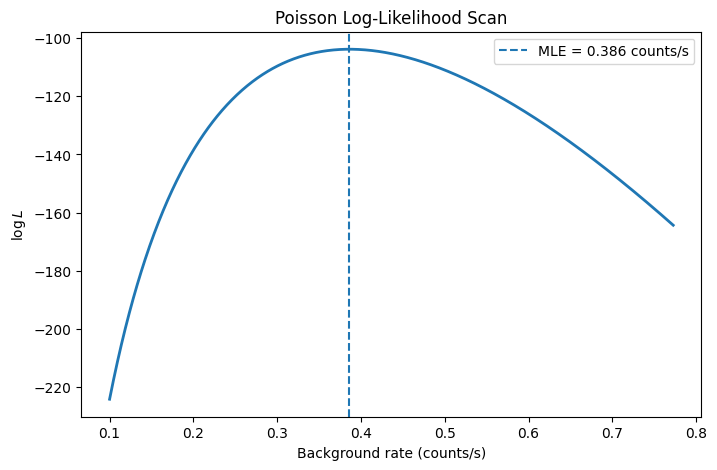

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    rate_values,
    log_likelihood,
    linewidth=2
)

plt.axvline(
    rate_bkg_mle,
    linestyle="--",
    label=rf"MLE = {rate_bkg_mle:.3f} counts/s"
)

plt.xlabel("Background rate (counts/s)")
plt.ylabel(r"$\log L$")
plt.title("Poisson Log-Likelihood Scan")
plt.legend()

plt.show()

## Interpretation

The likelihood scan confirms the analytical result.

The likelihood is maximized at approximately

$$
\boxed{\hat r_{\rm bkg}=\frac{\sum_iN_i}{nt}}.
$$

Thus, the background counting rate estimated from the GM measurements is the maximum-likelihood estimate of the Poisson rate parameter.

This gives us our first parameter estimate.



# Block 3 — Parameter Estimation for the Tl-204 Signal

When the Tl-204 source is placed near the GM detector, the observed counting rate contains contributions from both the background and the radioactive source:

$$
r_{\rm total}=r_{\rm bkg}+r_{\rm signal}.
$$

The number of observed counts during a measurement time $t$ is therefore modeled as

$$
N\sim\operatorname{Poisson}(\lambda),
$$

with

$$
\lambda=r_{\rm total}t.
$$

From the source measurements, the maximum-likelihood estimate of the total counting rate is

$$
\hat r_{\rm total}
=
\frac{\sum_i N_i}{nt}
=
\frac{\bar N}{t}.
$$

We already obtained an estimate of the background rate from the background-only measurements,

$$
\hat r_{\rm bkg}.
$$

Therefore, the estimated Tl-204 signal rate is

$$
\boxed{
\hat r_{\rm signal}
=
\hat r_{\rm total}-\hat r_{\rm bkg}
}.
$$


In [ ]:
# Number of Tl-204 measurements
n_source = len(source_counts)

# Counting time for source measurements
t_source = source_time[0]

# Total number of observed source counts
total_source_counts = np.sum(source_counts)

# Mean number of counts per source measurement
mean_source_counts = np.mean(source_counts)

# MLE of total rate with the source present
rate_total_mle = total_source_counts / (n_source * t_source)

# Estimated signal rate
rate_signal_mle = rate_total_mle - rate_bkg_mle

print(f"Number of source measurements = {n_source}")
print(f"Counting time per measurement = {t_source:.1f} s")
print(f"Total observed counts          = {total_source_counts}")
print(f"Mean source counts             = {mean_source_counts:.4f}")
print()

print(f"Background rate MLE = {rate_bkg_mle:.4f} counts/s")
print(f"Total rate MLE      = {rate_total_mle:.4f} counts/s")
print(f"Signal rate MLE     = {rate_signal_mle:.4f} counts/s")

Number of source measurements = 33
Counting time per measurement = 20.0 s
Total observed counts          = 368
Mean source counts             = 11.1515

Background rate MLE = 0.3863 counts/s
Total rate MLE      = 0.5576 counts/s
Signal rate MLE     = 0.1713 counts/s


## Comparing the Counting Rates

We can now compare the three rates:

$$
\hat r_{\rm bkg},
\qquad
\hat r_{\rm total},
\qquad
\hat r_{\rm signal}.
$$

The expected relationship is

$$
\hat r_{\rm total}
\approx
\hat r_{\rm bkg}
+
\hat r_{\rm signal}.
$$

It is useful to visualize the measured rates to see the separation between the background and source-plus-background samples.

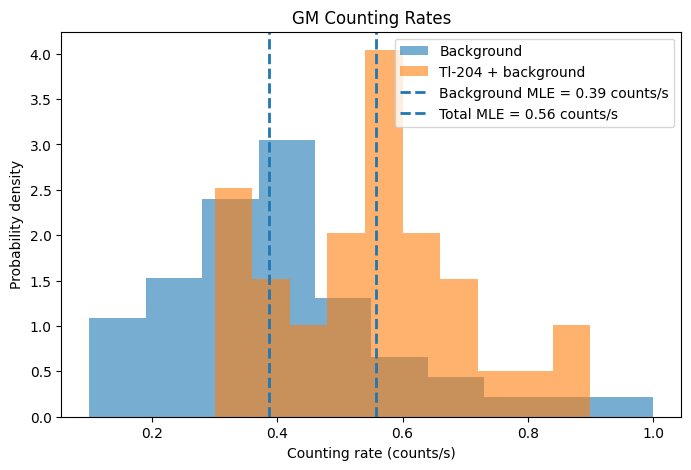

In [ ]:
# Calculate rates for every individual measurement
bkg_rates = bkg_counts / bkg_time
source_rates = source_counts / source_time

plt.figure(figsize=(8, 5))

plt.hist(
    bkg_rates,
    bins=10,
    alpha=0.6,
    density=True,
    label="Background"
)

plt.hist(
    source_rates,
    bins=10,
    alpha=0.6,
    density=True,
    label="Tl-204 + background"
)

plt.axvline(
    rate_bkg_mle,
    linestyle="--",
    linewidth=2,
    label=rf"Background MLE = {rate_bkg_mle:.2f} counts/s"
)

plt.axvline(
    rate_total_mle,
    linestyle="--",
    linewidth=2,
    label=rf"Total MLE = {rate_total_mle:.2f} counts/s"
)

plt.xlabel("Counting rate (counts/s)")
plt.ylabel("Probability density")
plt.title("GM Counting Rates")
plt.legend()

plt.show()

# Block 4 — Profile Likelihood for the Signal Rate

We now want to determine how well the signal rate $r_s$ is constrained by the data.

The model for the two datasets is

$$
N_i^{\rm bkg}\sim
\operatorname{Poisson}(r_b t_b),
$$

for the background measurements, and

$$
N_j^{\rm source}\sim
\operatorname{Poisson}\left[(r_b+r_s)t_s\right],
$$

for the measurements taken with the Tl-204 source.

Here,

- $r_b$ is the background counting rate,
- $r_s$ is the Tl-204 signal counting rate,
- $t_b$ is the background counting time,
- $t_s$ is the source counting time.

The likelihood for the complete dataset is

$$
L(r_s,r_b)
=
\prod_i
P(N_i^{\rm bkg}|r_b t_b)
\prod_j
P(N_j^{\rm source}|(r_b+r_s)t_s).
$$

It is more convenient to work with the log-likelihood,

$$
\ln L(r_s,r_b)
=
\sum_i
\ln P(N_i^{\rm bkg}|r_b t_b)
+
\sum_j
\ln P(N_j^{\rm source}|(r_b+r_s)t_s).
$$

For a fixed value of $r_s$, we maximize the likelihood with respect to $r_b$:

$$
\ln L_{\rm prof}(r_s)
=
\max_{r_b}
\ln L(r_s,r_b).
$$

This is called the **profile likelihood**.

The maximum-likelihood estimate of the signal rate is obtained from

$$
\hat r_s
=
\operatorname*{arg\,max}_{r_s}
\ln L_{\rm prof}(r_s).
$$

We define the profile likelihood ratio

$$
\lambda(r_s)
=
\frac{L_{\rm prof}(r_s)}
{L(\hat r_s,\hat r_b)}.
$$

Equivalently, we use

$$
q(r_s)
=
-2\ln\lambda(r_s)
=
2\left[
\ln L(\hat r_s,\hat r_b)
-
\ln L_{\rm prof}(r_s)
\right].
$$

At the best-fit point,

$$
q(\hat r_s)=0.
$$

The profile-likelihood curve tells us which values of the signal rate are compatible with the observed data.

In [ ]:
from scipy.special import gammaln
from scipy.optimize import minimize_scalar

def log_likelihood(rs, rb):
    """
    Log-likelihood for the complete GM counting experiment.

    rs = signal rate
    rb = background rate
    """

    # Physical requirement
    if rs < 0 or rb <= 0:
        return -np.inf

    # Expected counts
    lambda_bkg = rb * t_bkg
    lambda_source = (rb + rs) * t_source

    # Background contribution
    logL_bkg = np.sum(
        bkg_counts * np.log(lambda_bkg)
        - lambda_bkg
        - gammaln(bkg_counts + 1)
    )

    # Source + background contribution
    logL_source = np.sum(
        source_counts * np.log(lambda_source)
        - lambda_source
        - gammaln(source_counts + 1)
    )

    return logL_bkg + logL_source

## Profiling Over the Background Rate

For every assumed signal rate $r_s$, we find the value of $r_b$ that maximizes the likelihood.

Thus,

$$
\ln L_{\rm prof}(r_s)
=
\max_{r_b}\ln L(r_s,r_b).
$$

We perform this numerically using a one-dimensional minimization of the negative log-likelihood.

In [ ]:
# Signal-rate scan
signal_rates = np.linspace(
    0,
    max(2 * rate_signal_mle, 1.0),
    500
)

profile_logL = []
profile_bkg_rates = []

for rs in signal_rates:

    # Minimize negative log-likelihood with respect to rb
    result = minimize_scalar(
        lambda rb: -log_likelihood(rs, rb),
        bounds=(1e-6, max(2 * rate_total_mle, 1.0)),
        method="bounded"
    )

    profile_logL.append(-result.fun)
    profile_bkg_rates.append(result.x)

profile_logL = np.array(profile_logL)
profile_bkg_rates = np.array(profile_bkg_rates)

# Best-fit signal rate from profile likelihood
best_index = np.argmax(profile_logL)

best_signal_rate = signal_rates[best_index]
best_profile_logL = profile_logL[best_index]
best_profile_bkg = profile_bkg_rates[best_index]

print(f"Best-fit signal rate     = {best_signal_rate:.5f} counts/s")
print(f"Best-fit background rate = {best_profile_bkg:.5f} counts/s")
print(f"Maximum profile logL     = {best_profile_logL:.5f}")

Best-fit signal rate     = 0.17034 counts/s
Best-fit background rate = 0.38673 counts/s
Maximum profile logL     = -188.20213


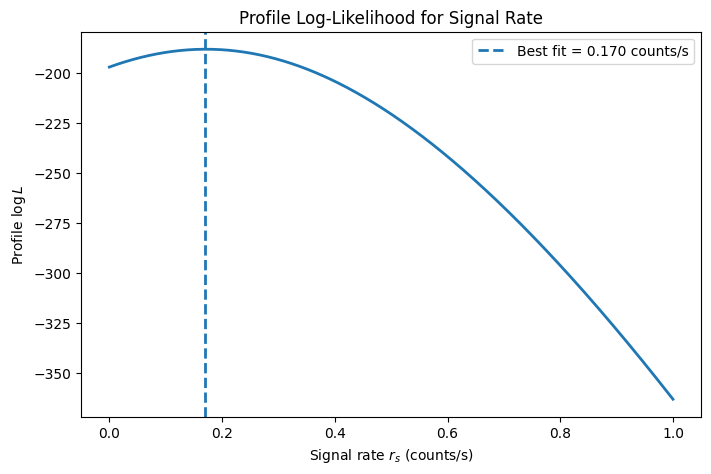

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(
    signal_rates,
    profile_logL,
    linewidth=2
)

plt.axvline(
    best_signal_rate,
    linestyle="--",
    linewidth=2,
    label=rf"Best fit = {best_signal_rate:.3f} counts/s"
)

plt.xlabel(r"Signal rate $r_s$ (counts/s)")
plt.ylabel(r"Profile $\log L$")
plt.title("Profile Log-Likelihood for Signal Rate")
plt.legend()

plt.show()

#2D Liklihood Scan in (rs,rb)

In [ ]:
# ------------------------------------------
# 2D likelihood scan in (rs, rb)
# ------------------------------------------

rs_values_2d = np.linspace(
    0,
    max(2 * rate_signal_mle, 1.0),
    150
)

rb_values_2d = np.linspace(
    0.05,
    max(2 * rate_total_mle, 1.0),
    150
)

RS, RB = np.meshgrid(
    rs_values_2d,
    rb_values_2d
)

logL_2d = np.zeros_like(RS)

for i in range(len(rb_values_2d)):
    for j in range(len(rs_values_2d)):

        logL_2d[i, j] = log_likelihood(
            RS[i, j],
            RB[i, j]
        )

# Global maximum
max_index = np.unravel_index(
    np.argmax(logL_2d),
    logL_2d.shape
)

best_rs_2d = RS[max_index]
best_rb_2d = RB[max_index]
max_logL_2d = logL_2d[max_index]

print(f"Best-fit signal rate     = {best_rs_2d:.5f} counts/s")
print(f"Best-fit background rate = {best_rb_2d:.5f} counts/s")

Best-fit signal rate     = 0.17450 counts/s
Best-fit background rate = 0.38599 counts/s


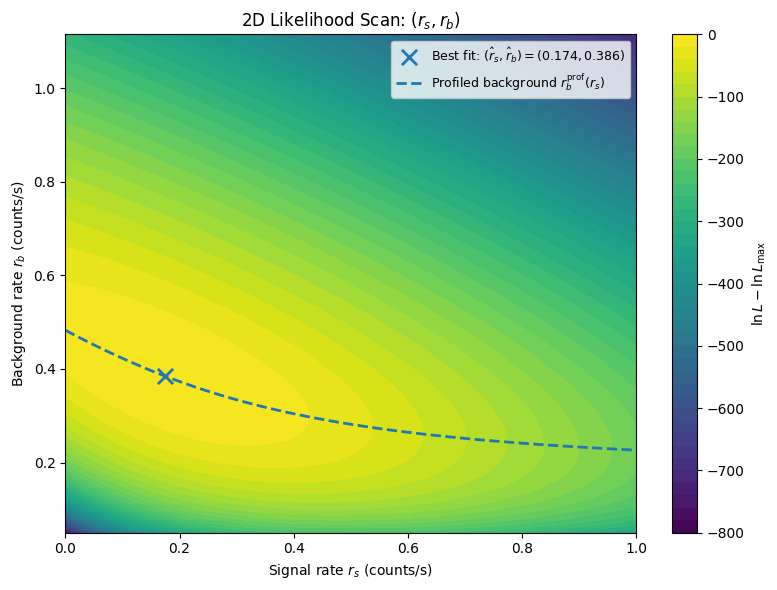

In [ ]:
plt.figure(figsize=(8, 6))

# Relative log-likelihood
delta_logL_2d = logL_2d - max_logL_2d

plt.contourf(
    RS,
    RB,
    delta_logL_2d,
    levels=50
)

plt.colorbar(
    label=r"$\ln L-\ln L_{\max}$"
)

# Global maximum
plt.scatter(
    best_rs_2d,
    best_rb_2d,
    marker="x",
    s=120,
    linewidths=2,
    label=rf"Best fit: $(\hat{{r}}_s,\hat{{r}}_b)=({best_rs_2d:.3f},{best_rb_2d:.3f})$"
)

# Profiled background
plt.plot(
    signal_rates,
    profile_bkg_rates,
    linestyle="--",
    linewidth=2,
    label=r"Profiled background $r_b^{\mathrm{prof}}(r_s)$"
)

plt.xlabel(r"Signal rate $r_s$ (counts/s)")
plt.ylabel(r"Background rate $r_b$ (counts/s)")
plt.title(r"2D Likelihood Scan: $(r_s,r_b)$")

plt.legend(
    loc="upper right",
    fontsize=9
)

plt.tight_layout()
plt.show()

## Profile Likelihood Ratio

It is more convenient to subtract the maximum likelihood value:

$$
q(r_s)
=
-2\left[
\ln L_{\rm prof}(r_s)
-
\ln L_{\rm max}
\right].
$$

Therefore,

$$
\boxed{
q(r_s)
=
2\left[
\ln L_{\rm max}
-
\ln L_{\rm prof}(r_s)
\right].
}
$$

The minimum occurs at the best-fit signal rate:

$$
q(\hat r_s)=0.
$$

Under the usual large-sample approximation, $q(r_s)$ can be related to confidence intervals.

For one parameter, commonly used approximate thresholds are

$$
q=1
$$

for approximately a $68\%$ confidence interval, and

$$
q=3.84
$$

for approximately a $95\%$ confidence interval.

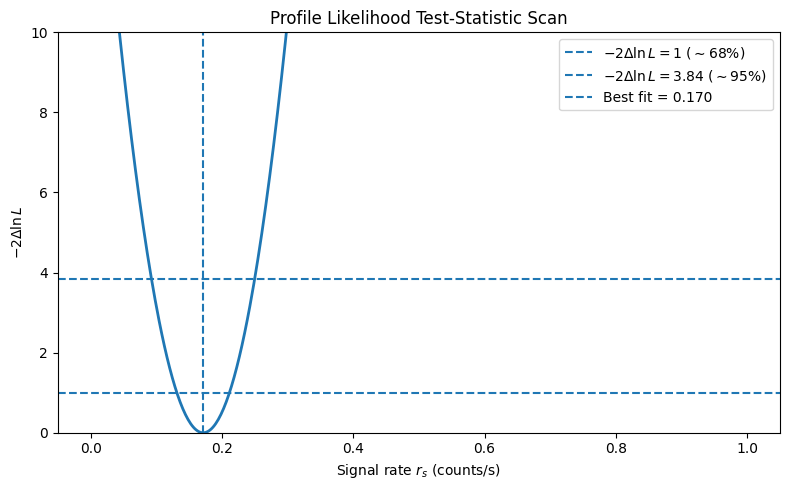

In [ ]:
# -2 Delta log-likelihood
q_signal = 2 * (
    best_profile_logL - profile_logL
)

plt.figure(figsize=(8, 5))

plt.plot(
    signal_rates,
    q_signal,
    linewidth=2
)

# Approximate confidence thresholds
plt.axhline(
    1.0,
    linestyle="--",
    label=r"$-2\Delta\ln L=1$ ($\sim68\%$)"
)

plt.axhline(
    3.84,
    linestyle="--",
    label=r"$-2\Delta\ln L=3.84$ ($\sim95\%$)"
)

# Best fit
plt.axvline(
    best_signal_rate,
    linestyle="--",
    label=rf"Best fit = {best_signal_rate:.3f}"
)

plt.ylim(0, 10)

plt.xlabel(r"Signal rate $r_s$ (counts/s)")
plt.ylabel(r"$-2\Delta\ln L$")
plt.title("Profile Likelihood Test-Statistic Scan")

plt.legend()
plt.tight_layout()
plt.show()

## Interpretation

The profile-likelihood scan gives a direct estimate of the signal rate and its allowed range.

The best-fit value is

$$
\boxed{\hat r_s \approx \text{value obtained from the scan}}.
$$

The region around the minimum corresponds to signal rates that provide likelihoods close to the maximum.

Using the approximate likelihood-ratio thresholds,

$$
-2\Delta\ln L=1
$$

and

$$
-2\Delta\ln L=3.84,
$$

we can obtain approximate $68\%$ and $95\%$ confidence intervals for the signal rate.

An important feature of this method is that the uncertainty in the background rate is included automatically through profiling over the nuisance parameter $r_b$.

In the next block, we will perform the **background-only hypothesis test** and calculate the **p-value** for the hypothesis

$$
H_0:r_s=0.
$$

# Block 5 — Hypothesis Test and p-value

We now test whether the observed data are compatible with the background-only hypothesis.

The null hypothesis is

$$
H_0:r_s=0,
$$

meaning that there is no contribution from the Tl-204 source.

The alternative hypothesis is

$$
H_1:r_s>0.
$$

We use the profile likelihood to construct a likelihood-ratio test statistic.

For the background-only hypothesis, we fix

$$
r_s=0
$$

and maximize the likelihood with respect to the background rate $r_b$:

$$
\ln L_0
=
\max_{r_b}\ln L(r_s=0,r_b).
$$

The unrestricted maximum likelihood is

$$
\ln L_{\rm max}
=
\max_{r_s,r_b}\ln L(r_s,r_b).
$$

We define the likelihood-ratio test statistic as

$$
q_0
=
-2\ln
\left(
\frac{L_0}{L_{\rm max}}
\right).
$$

Equivalently,

$$
\boxed{
q_0
=
2\left[
\ln L_{\rm max}-\ln L_0
\right].
}
$$

A large value of $q_0$ indicates that the background-only hypothesis provides a poorer description of the observed data compared with the signal-plus-background hypothesis.

According to **Wilks' theorem**, under the null hypothesis and for sufficiently large sample sizes, the likelihood-ratio test statistic follows a chi-square distribution with one degree of freedom:

$$
q_0\sim\chi^2_1.
$$

Therefore, the p-value is the probability of obtaining a value of the test statistic at least as large as the observed value:

$$
\boxed{
p_0
=
P(\chi^2_1\geq q_0^{\rm obs})
}.
$$

Using the survival function of the $\chi^2$ distribution,

$$
\boxed{
p_0
=
1-F_{\chi^2_1}(q_0^{\rm obs})
}.
$$

The corresponding Gaussian-equivalent significance is obtained from

$$
\boxed{
Z=\Phi^{-1}(1-p_0)
}
$$

where $\Phi$ is the cumulative distribution function of the standard normal distribution.

Thus, the hypothesis test allows us to quantify how strongly the data disfavor the background-only hypothesis in terms of both a p-value and a Gaussian-equivalent significance.

In [ ]:
from scipy.optimize import minimize_scalar
from scipy.stats import norm

# Background-only hypothesis:
# signal rate is fixed to zero

result_bkg_only = minimize_scalar(
    lambda rb: -log_likelihood(0.0, rb),
    bounds=(1e-6, max(2 * rate_total_mle, 1.0)),
    method="bounded"
)

best_rb_null = result_bkg_only.x
logL_null = -result_bkg_only.fun

print(f"Background-only fitted rate = {best_rb_null:.6f} counts/s")
print(f"Background-only logL         = {logL_null:.6f}")

Background-only fitted rate = 0.482906 counts/s
Background-only logL         = -197.126643


In [ ]:
# Likelihood-ratio test statistic

q0 = 2 * (
    best_profile_logL - logL_null
)

# Numerical precision can occasionally produce tiny negative values
q0 = max(q0, 0)

# Asymptotic p-value for one-sided test
p_value = 1 - norm.cdf(np.sqrt(q0))

# Corresponding significance
Z = norm.ppf(1 - p_value)

print(f"q0       = {q0:.5f}")
print(f"p-value  = {p_value:.6g}")
print(f"Significance Z = {Z:.4f} sigma")

q0       = 17.84902
p-value  = 1.19571e-05
Significance Z = 4.2248 sigma


## Interpretation

The p-value answers the question:

> If there were actually no Tl-204 signal, how likely would we be to obtain data at least as signal-like as the data observed?

We have tested

$$
H_0:r_s=0.
$$

The calculated p-value is

$$
\boxed{p_0=\text{value obtained above}}.
$$

A small p-value indicates that the observed excess is unlikely to be explained by background fluctuations alone.

The corresponding significance is

$$
Z=\Phi^{-1}(1-p_0).
$$

Thus, the result can be expressed either as a p-value or as a Gaussian-equivalent significance in units of $\sigma$.

For example,

$$
Z=1\sigma,\;2\sigma,\;3\sigma,\ldots
$$

correspond to progressively stronger evidence against the background-only hypothesis.

Importantly, a small p-value does **not** mean that the probability of the null hypothesis being true is small. It means that the observed data would be unlikely under the null hypothesis.

# Block 6 — Exact Poisson p-value

The likelihood-ratio calculation above used an asymptotic approximation for the distribution of the test statistic.

Since this is a counting experiment, we can instead perform an exact calculation using the Poisson distribution.

Under the background-only hypothesis,

$$
H_0:r_s=0,
$$

the expected number of counts in a source measurement is

$$
\lambda_0=r_b t_s.
$$

We estimate $r_b$ from the independent background measurements:

$$
\hat r_b
=
\frac{\sum_i N_i^{\rm bkg}}
{n_{\rm bkg}t_b}.
$$

Therefore, under $H_0$,

$$
\lambda_0=\hat r_b t_s.
$$

The total number of counts observed in the source measurements is

$$
N_{\rm obs}
=
\sum_j N_j^{\rm source}.
$$

Since the source measurements are independent Poisson variables with the same mean, their sum is also Poisson distributed:

$$
N_{\rm total}
\sim
\operatorname{Poisson}
\left(n_{\rm source}\lambda_0\right).
$$

Thus the expected total number of counts under the background-only hypothesis is

$$
\boxed{
\Lambda_0
=
n_{\rm source}\hat r_b t_s
}.
$$

Because our alternative hypothesis is an excess of counts,

$$
H_1:r_s>0,
$$

we use an upper-tail probability.

The exact Poisson p-value is therefore

$$
\boxed{
p_{\rm exact}
=
P(N\geq N_{\rm obs}\mid\Lambda_0)
}.
$$

For a Poisson distribution this can be calculated using the survival function:

$$
p_{\rm exact}
=
\operatorname{P}(N\geq N_{\rm obs}).
$$

In [ ]:
from scipy.stats import poisson, norm
import numpy as np

# ==========================================
# Background-only Poisson hypothesis test
# ==========================================

# Background measurements
N_bkg_total = np.sum(bkg_counts)
T_bkg_total = np.sum(bkg_time)

# MLE of background counting rate
r_bkg = N_bkg_total / T_bkg_total

# Source measurements
N_obs = np.sum(source_counts)
T_source_total = np.sum(source_time)

# Expected number of background counts
# in the total source measurement time
lambda_bkg = r_bkg * T_source_total

# Exact one-sided Poisson p-value
# P(N >= N_obs | lambda_bkg)
p_exact = poisson.sf(N_obs - 1, lambda_bkg)

# Convert p-value to Gaussian-equivalent significance
Z_exact = norm.isf(p_exact)

# Print results
print("======================================")
print("      Exact Poisson Hypothesis Test")
print("======================================")

print(f"Total background counts = {N_bkg_total}")
print(f"Total background time   = {T_bkg_total:.1f} s")
print(f"Background rate         = {r_bkg:.6f} counts/s")
print()

print(f"Observed source counts  = {N_obs}")
print(f"Total source time      = {T_source_total:.1f} s")
print(f"Expected background    = {lambda_bkg:.4f}")
print()

print(f"Exact Poisson p-value   = {p_exact:.6e}")
print(f"Gaussian significance   = {Z_exact:.4f} sigma")
print("======================================")

      Exact Poisson Hypothesis Test
Total background counts = 197
Total background time   = 510.0 s
Background rate         = 0.386275 counts/s

Observed source counts  = 368
Total source time      = 660.0 s
Expected background    = 254.9412

Exact Poisson p-value   = 1.823766e-11
Gaussian significance   = 6.6177 sigma


## Discussion Question: Comparing the Two Significance Estimates

The profile-likelihood test (Block 5) gives $Z \approx 4.22\sigma$, while the exact
Poisson test (Block 6) gives $Z \approx 6.62\sigma$, for the same dataset.

**Why do these two tests disagree so substantially? Which one, if either, should be
considered more reliable, and why?**

